# **Importing Modules & Installing RDKit**



In [3]:
from rdkit import Chem
from rdkit.Chem import Descriptors
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score




# **Loading the Excel and Cleaning  the  Dataset**

In [24]:
file_path = "/content/DILIrank-DILIscore_List.xlsx"
xls = pd.ExcelFile(file_path)
df = xls.parse("DILIrank")
df.columns = df.iloc[0]
df = df[1:]
df = df[['Compound Name', 'vDILIConcern']]
df = df.dropna()
df.head()


,Compound Name,vDILIConcern
1,mercaptopurine,vMost-DILI-Concern
2,acetaminophen,vMost-DILI-Concern
3,azathioprine,vMost-DILI-Concern
4,chlorpheniramine,vNo-DILI-Concern
5,clofibrate,vLess-DILI-Concern


# **Exploratory Data Analysis (EDA)**

Shape of dataset: (1036, 2)

First 5 rows:
0     Compound Name        vDILIConcern
1    mercaptopurine  vMost-DILI-Concern
2     acetaminophen  vMost-DILI-Concern
3      azathioprine  vMost-DILI-Concern
4  chlorpheniramine    vNo-DILI-Concern
5        clofibrate  vLess-DILI-Concern

Missing values:
0
Compound Name    0
vDILIConcern     0
dtype: int64

Data types:
0
Compound Name    object
vDILIConcern     object
dtype: object

Unique DILI Concern Classes:
vDILIConcern
vNo-DILI-Concern          312
vLess-DILI-Concern        278
Ambiguous DILI-concern    254
vMost-DILI-Concern        192
Name: count, dtype: int64


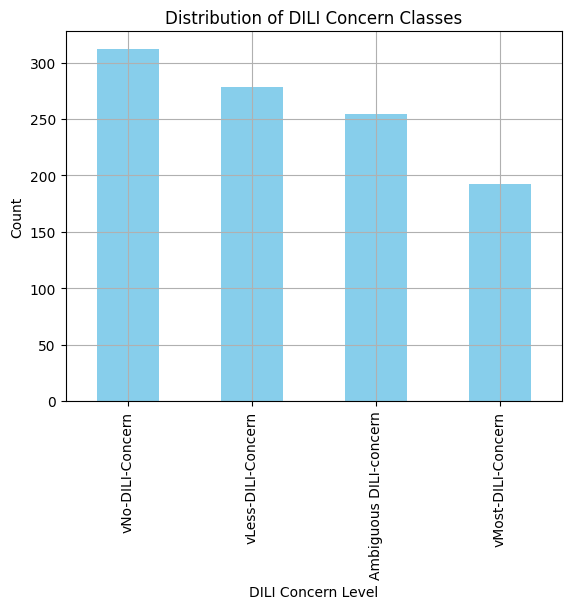

In [25]:
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing values:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)
print("\nUnique DILI Concern Classes:")
print(df['vDILIConcern'].value_counts())
import matplotlib.pyplot as plt

df['vDILIConcern'].value_counts().plot(kind='bar', color='skyblue')
plt.title("Distribution of DILI Concern Classes")
plt.xlabel("DILI Concern Level")
plt.ylabel("Count")
plt.grid(True)
plt.show()


# **Label Encoding DILI Classes**

In [26]:
label_map = {
    'vMost-DILI-Concern': 3,
    'Ambiguous DILI-concern': 1,
    'vLess-DILI-Concern': 2,
    'vNo-DILI-Concern': 0
}
df['Label'] = df['vDILIConcern'].map(label_map)
df = df.dropna(subset=['Label'])
df[['Compound Name', 'vDILIConcern', 'Label']].head()


,Compound Name,vDILIConcern,Label
1,mercaptopurine,vMost-DILI-Concern,3
2,acetaminophen,vMost-DILI-Concern,3
3,azathioprine,vMost-DILI-Concern,3
4,chlorpheniramine,vNo-DILI-Concern,0
5,clofibrate,vLess-DILI-Concern,2


# **Preprocessing Compound Names & Fetching SMILES**

In [7]:
!pip install cirpy

  Using cached CIRpy-1.0.2-py3-none-any.whl


In [27]:
import re
import cirpy
def clean_name(name):
    name = name.strip().lower()
    name = re.sub(r"[^a-z0-9\s]", "", name)
    name = name.replace(" recombinant", "")
    name = name.replace("human", "")
    return name

def get_smiles(name):
    try:
        return cirpy.resolve(name, 'smiles')
    except:
        return None

df['CleanName'] = df['Compound Name'].apply(clean_name)
df['SMILES'] = df['CleanName'].apply(get_smiles)

df = df.dropna(subset=['SMILES'])

df[['Compound Name', 'CleanName', 'SMILES', 'Label']].head()


,Compound Name,CleanName,SMILES,Label
1,mercaptopurine,mercaptopurine,S=C1N=CNc2nc[nH]c12,3
2,acetaminophen,acetaminophen,CC(=O)Nc1ccc(O)cc1,3
3,azathioprine,azathioprine,Cn1cnc(c1Sc2ncnc3nc[nH]c23)[N+]([O-])=O,3
4,chlorpheniramine,chlorpheniramine,CN(C)CCC(c1ccc(Cl)cc1)c2ccccn2.OC(=O)\C=C/C(O)=O,0
5,clofibrate,clofibrate,CCOC(=O)C(C)(C)Oc1ccc(Cl)cc1,2


# **Descriptor Extraction Using RDKit**

In [36]:
from rdkit import Chem
from rdkit.Chem import Descriptors
descriptor_functions = {
    'MolLogP': Descriptors.MolLogP,
    'TPSA': Descriptors.TPSA,
    'ExactMolWt': Descriptors.ExactMolWt,
    'BalabanJ': Descriptors.BalabanJ,
    'NumRotatableBonds': Descriptors.NumRotatableBonds,
    'RingCount': Descriptors.RingCount,
    'BertzCT': Descriptors.BertzCT,
    'Chi0v': Descriptors.Chi0v
}

def compute_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return [None]*len(descriptor_functions)
    return [func(mol) for func in descriptor_functions.values()]

desc_names = list(descriptor_functions.keys())
desc_values = df['SMILES'].apply(compute_descriptors)
desc_df = pd.DataFrame(desc_values.tolist(), columns=desc_names)

df_full = pd.concat([df[['Compound Name', 'SMILES', 'Label']], desc_df], axis=1)

df_full = df_full.dropna()

df_full.head()


[10:52:59] WARNING: not removing hydrogen atom without neighbors
[10:52:59] WARNING: not removing hydrogen atom without neighbors
[10:52:59] WARNING: not removing hydrogen atom without neighbors
[10:52:59] WARNING: not removing hydrogen atom without neighbors
[10:52:59] WARNING: not removing hydrogen atom without neighbors
[10:52:59] WARNING: not removing hydrogen atom without neighbors
[10:53:00] WARNING: not removing hydrogen atom without neighbors
[10:53:00] WARNING: not removing hydrogen atom without neighbors
[10:53:00] WARNING: not removing hydrogen atom without neighbors
[10:53:01] SMILES Parse Error: syntax error while parsing: [Fe](|[N]=O)(|[C]#N)(|[C]#N)(|[C]#N)(|[C]#N)|[C]#N
[10:53:01] SMILES Parse Error: Failed parsing SMILES '[Fe](|[N]=O)(|[C]#N)(|[C]#N)(|[C]#N)(|[C]#N)|[C]#N' for input: '[Fe](|[N]=O)(|[C]#N)(|[C]#N)(|[C]#N)(|[C]#N)|[C]#N'
[10:53:02] WARNING: not removing hydrogen atom without neighbors
[10:53:02] WARNING: not removing hydrogen atom without neighbors
[10:5

,Compound Name,SMILES,Label,MolLogP,TPSA,ExactMolWt,BalabanJ,NumRotatableBonds,RingCount,BertzCT,Chi0v
1,mercaptopurine,S=C1N=CNc2nc[nH]c12,3.0,1.3506,49.33,151.063329,2.736298e+00,1.0,1.0,253.299498,6.164863
2,acetaminophen,CC(=O)Nc1ccc(O)cc1,3.0,1.1458,115.42,277.038193,2.083458e+00,3.0,3.0,764.862315,10.456574
3,azathioprine,Cn1cnc(c1Sc2ncnc3nc[nH]c23)[N+]([O-])=O,3.0,3.5304,90.73,390.134635,3.872368e-07,7.0,2.0,730.336845,16.004311
4,chlorpheniramine,CN(C)CCC(c1ccc(Cl)cc1)c2ccccn2.OC(=O)\C=C/C(O)=O,0.0,3.0605,35.53,242.070972,2.715496e+00,4.0,1.0,357.031552,10.375146
5,clofibrate,CCOC(=O)C(C)(C)Oc1ccc(Cl)cc1,2.0,1.8840,41.57,260.024820,2.582264e+00,5.0,1.0,201.866476,10.322885


# **Model Training – RandomForestClassifier**

In [37]:
import numpy as np
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

X = df_full.drop(['Compound Name', 'SMILES', 'Label'], axis=1)
y = df_full['Label']

X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(X.mean(), inplace=True)

sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X, y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42)


In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)



RandomForestClassifier(random_state=42)

# **Model Evaluation**

In [39]:
y_pred = rf_model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[18 12  9  8]
 [ 6 16 17  7]
 [13  9 11 14]
 [ 7 10  7 23]]
              precision    recall  f1-score   support

         0.0       0.41      0.38      0.40        47
         1.0       0.34      0.35      0.34        46
         2.0       0.25      0.23      0.24        47
         3.0       0.44      0.49      0.46        47

    accuracy                           0.36       187
   macro avg       0.36      0.36      0.36       187
weighted avg       0.36      0.36      0.36       187



# **SMILES Based DILI Prediction**

In [45]:
def predict_dili_class_8desc(compound_name, model, scaler):
    from rdkit import Chem
    from rdkit.Chem import Descriptors
    import pandas as pd
    import cirpy
    import re

    def resolve_smiles(name):
        try:
            return cirpy.resolve(name, 'smiles')
        except:
            return None

    def preprocess_name(name):
        name = name.strip().lower()
        name = re.sub(r"[^a-z0-9\s]", "", name)
        name = name.replace("recombinant", "")
        name = name.replace("human", "")
        return name

    name = preprocess_name(compound_name)
    smiles = resolve_smiles(name)

    if not smiles:
        return f"Could not resolve SMILES for {compound_name}"

    mol = Chem.MolFromSmiles(smiles)
    if not mol:
        return f"RDKit could not parse SMILES for {compound_name}"

    props = {
        'MolLogP': Descriptors.MolLogP(mol),
        'TPSA': Descriptors.TPSA(mol),
        'ExactMolWt': Descriptors.ExactMolWt(mol),
        'BalabanJ': Descriptors.BalabanJ(mol),
        'NumRotatableBonds': Descriptors.NumRotatableBonds(mol),
        'RingCount': Descriptors.RingCount(mol),
        'BertzCT': Descriptors.BertzCT(mol),
        'Chi0v': Descriptors.Chi0v(mol)
    }

    X_new = pd.DataFrame([props])
    X_new.fillna(X_new.mean(), inplace=True)
    X_scaled = scaler.transform(X_new)

    pred = model.predict(X_scaled)[0]

    label_map = {
        0: 'No-DILI-Concern',
        1: 'Ambiguous DILI-Concern',
        2: 'Less-DILI-Concern',
        3: 'Most-DILI-Concern'
    }

    return f"Prediction for {compound_name}: {label_map.get(int(pred), 'Unknown')}"


In [46]:
print(predict_dili_class_8desc("Ibuprofen", rf_model, scaler))
print(predict_dili_class_8desc("Aspirin", rf_model, scaler))
print(predict_dili_class_8desc("Acetaminophen", rf_model, scaler))

Prediction for Ibuprofen: Most-DILI-Concern
Prediction for Aspirin: Less-DILI-Concern
Prediction for Acetaminophen: Most-DILI-Concern
